In [143]:
import numpy as np
import matplotlib.pyplot as plt
import math
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import random

In [144]:
def generate_data(n_sample, x_range, noise_std, random_x):
    y = []

    if random_x:
        x = np.random.uniform(x_range[0], x_range[1], n_sample)
    else:
        x = np.linspace(x_range[0], x_range[1], n_sample)

    for idx, item in enumerate(x):
        if noise_std > 0:
            y.append(true_func(item)+ noise_std)
        else:
            y.append(true_func(item))

    return x, np.array(y)


def true_func(x, a=3, b=-2, c=2, d=1):
    return ((x**3) * a) + ((x**2) * b) + (x * c) + d


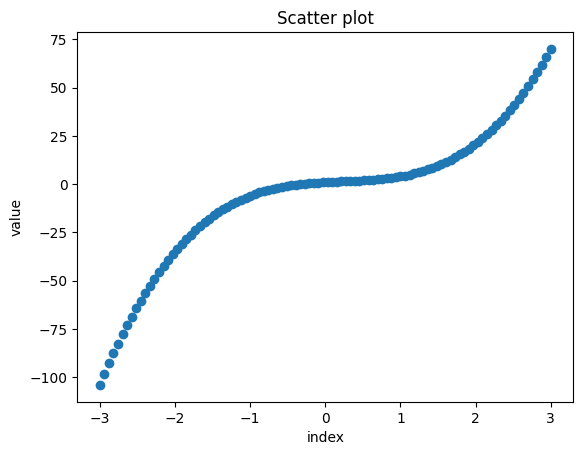

In [145]:
x_test, y_test = generate_data(100, (-3, 3), 0, False)
plt.scatter(x_test, y_test)
plt.xlabel("index")
plt.ylabel("value")
plt.title("Scatter plot")
plt.show()

In [146]:
degrees = [1, 2, 3, 4, 5, 6]
predicted_value = {}

for degree in degrees:
    degree_predicted_value = []
    for i in range(50):
        train_x, train_y = generate_data(100, (-3, 3), random.random(), True)
        train_x = train_x.reshape(-1, 1)

        poly = PolynomialFeatures(degree=degree, include_bias=False)
        train_x_ready = poly.fit_transform(train_x)

        lr = LinearRegression()
        lr.fit(train_x_ready, train_y)

        #print(f"Original X_train shape: {train_x.shape}")
        #print(f"Polynomial X_train shape (degree {degree}): {train_x_ready.shape}")

        y_predict = lr.predict(poly.transform(x_test.reshape(-1, 1)))
        degree_predicted_value.append(y_predict)

        model_score = lr.score(poly.transform(x_test.reshape(-1, 1)), y_test)

    predicted_value[f'degree_{degree}'] = np.array(degree_predicted_value)



In [147]:
means = predicted_value['degree_1'].mean(axis=0)
mean_dict = {}
variance_dict = {}
for key in predicted_value:
    mean = predicted_value[key].mean(axis=0)
    variance = predicted_value[key].var(axis=0)
    mean_dict[f'mean_{key}'] = mean
    variance_dict[f'variance_{key}'] = variance

In [148]:
bias_dict = {}
i = 0
for key in mean_dict:
    bias_arr = []
    for idx, item in enumerate(mean_dict[key]):
        bias = item - y_test[idx]
        bias_arr.append(bias)
    i = i + 1
    bias_dict[f'bias_degree_{i}'] = bias_arr

In [149]:
err_dict = {}
i = 0
for (k1, v), (k2, b) in zip(variance_dict.items(), bias_dict.items()):
    err_arr = []
    for variance,bias in zip(v, b):
        err = bias ** 2 + variance
        err_arr.append(err)
    i = i + 1
    err_dict[f'err_degree_{i}'] = err_arr

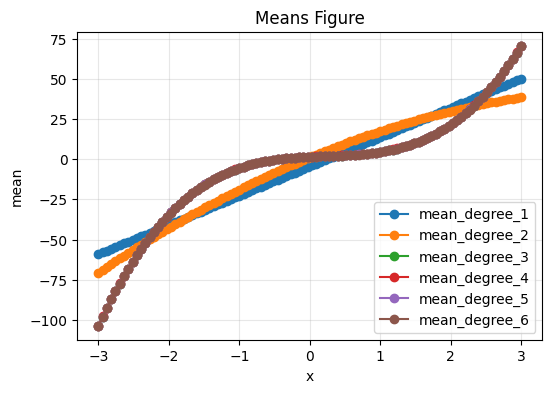

In [150]:
plt.figure(figsize=(6,4))

for k, y in mean_dict.items():
    plt.plot(x_test, y, marker='o', label=k)

plt.xlabel('x')
plt.ylabel('mean')
plt.title('Means Figure')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

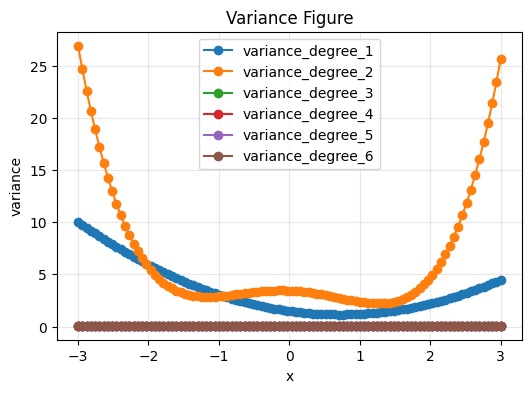

In [151]:
plt.figure(figsize=(6,4))

for k, y in variance_dict.items():
    plt.plot(x_test, y, marker='o', label=k)

plt.xlabel('x')
plt.ylabel('variance')
plt.title('Variance Figure')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

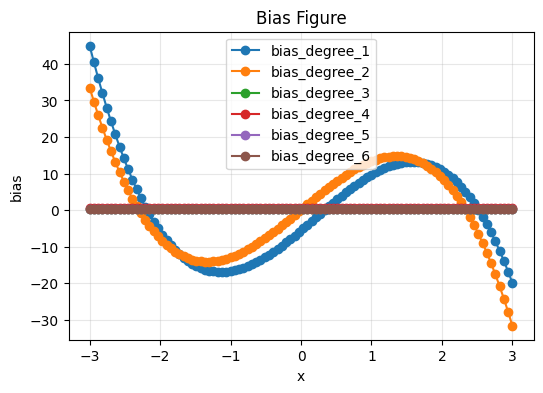

In [152]:
plt.figure(figsize=(6,4))

for k, y in bias_dict.items():
    plt.plot(x_test, y, marker='o', label=k)

plt.xlabel('x')
plt.ylabel('bias')
plt.title('Bias Figure')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

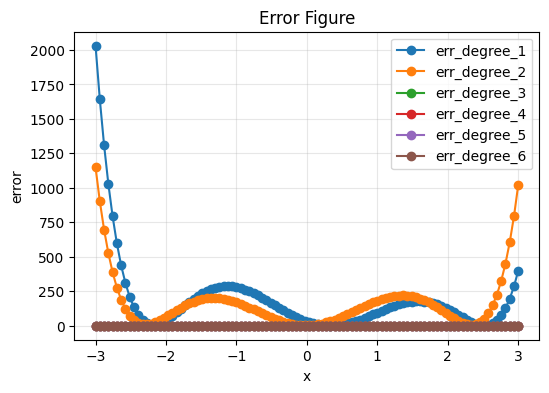

In [153]:
plt.figure(figsize=(6,4))

for k, y in err_dict.items():
    plt.plot(x_test, y, marker='o', label=k)

plt.xlabel('x')
plt.ylabel('error')
plt.title('Error Figure')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()